# Example
## Reisudal Box Plot as Fucntion of $x$ 

An example showing the use of ```inspect.boxplot_vx```. This function is used to visualize how a dataset $y$ is distrubted and varies as a function of a secondary dataset $x$. The SciPy ```stats.binned_statistic``` function is used to bin the dataset as a function $x$ and calculate the neccessary statistics as a function of $y$ for a box and whisker plot.

At each $x$ bin, box and whisker values are derived for $y$ which can be plotted using ```matplotlib.axes.Axes.bxp```.

```inspect.boxplot_vx``` can calculate box and whisker values for an arbitrary number of $x$ datasets which are passed as Pandas DataFrame.

```inspect.boxplot_vx``` was developed to investigate how model residuals (observations-predictions) vary as a function of model features. However it can be applied to any dataset to visualize how $y$ varies as a function $x$. 

The example here shows how model residuals vary as function of geomagnetic conditions as measured by AE and Sym-H. The model file ```RF_FI_GEO_OOS_CHAMP.hdf5``` contains the predicted and observed density along the CHAMP satellite orbit. The predicted density is from a random forest model of atmospheric neutral density at 400 km altitude. 



In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

path_dat = "E:\OneDrive\Phys4501\data\RF_FI_GEO_OOS_CHAMP.hdf5"
path_mod = os.path.normpath(os.getcwd()+'/../ml_fw/') # assumes current working directory is the ml_fw/Notebooks directory


In [3]:
path_mod

# add the ml_fw module to Python Path and import what we need
sys.path.append(os.path.dirname(path_mod))

'd:\\GitHub\\ml_fw\\ml_fw'

In [4]:
import ml_fw.inspect as inspect

In [5]:
# load the data set and calculate the residuals
dat = pd.read_hdf(path_dat)
dat['resid'] = dat['400kmDensity']-dat['400kmDensity_pred']

In [6]:
# define the x_cols of dat that we want to use for binning
# and their ranges and number of bins
x_dat = ['AE', 'SYM_H index']
x_bin = [20,21]
x_range = [[0,2000], [-200,10]]
# the y_col to derive the stats
y_dat = ['resid']

whisker = 0 # don't want whiskers
showmean = True # plot the means

In [7]:
# derive the box/whisker data for each x dat
box_dat = inspect.boxplot_vx(dat[x_dat],dat[y_dat], whisker=whisker,
                           bins=x_bin,xrange=x_range)

AE
SYM_H index


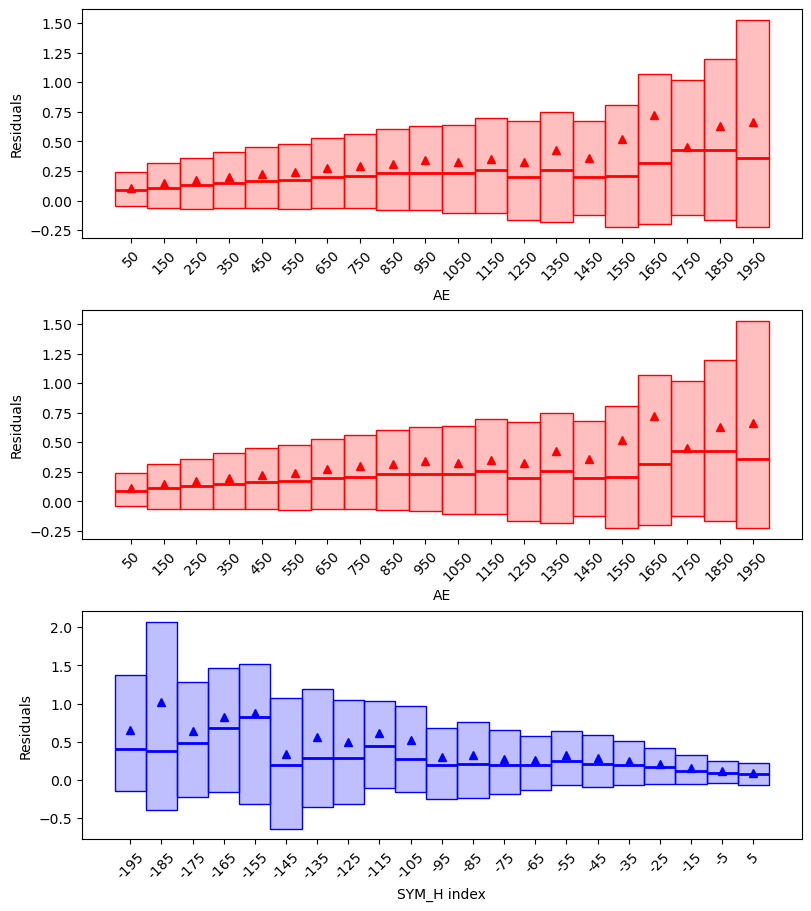

In [10]:
# plot the data
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(3,1, figsize=(8,9))
fig.set_constrained_layout(True)

# boxplot_vx returns a dictionary for each of x_dat which contains 
# the required values to plot a boxplot using bxp()
# the dictionary key is the inputs DataFramed column names

# lets look at the returned dictionary for AE
ae_box = box_dat['AE'] # the AE box/whisker data
y_val = ae_box['box_stats'] # a list of dictionaries for each box/whisker instance
x_val = ae_box['x_centre'] # the center of each x bin
x_width = ae_box['x_width'] # the width of each x bin

# lets define some colors, alpha values (transparencies) and other properties to
# make the plot pretty 

cc = [1,0,0] # red box plot
bx_a = 0.25 # transparency level (alpha) for box
ln_a = 1.0 # transparency level for lines
ln_w = 2.0 # line width

b1 = ax[0].bxp(y_val, positions=x_val, widths=x_width, 
                  patch_artist=True, showmeans=showmean, 
                  shownotches=False, showcaps=False, 
                  boxprops={'ec':cc+[ln_a], 'fc':cc+[bx_a]}, # artist properties for boxes
                  medianprops={'c':cc, 'lw':ln_w}, # artist properties for medians
                  meanprops={'mec':cc, 'mfc':cc}) # artist propoerties for means

# lets fix the x-axis a bit and label everything
ax[0].set_xticks(x_val,x_val.astype(int).astype(str),rotation=45)
ax[0].set_ylabel('Residuals')
ax[0].set_xlabel('AE')

# lets do the same thing but loop through the returned box_dat
# to create a box/whisker plot for each returned key (x_dat)
# loop through the dictionary to plot all box_plots
pc = [cc, [0,0,1]]
for (key, value), ap, bc, in zip(box_dat.items(), ax[1:], pc):
    print(key)
    plt_box = box_dat[key]
    y_val = plt_box['box_stats']
    x_val = plt_box['x_centre']
    x_width = plt_box['x_width']
    
    b = ap.bxp(y_val, positions=x_val, widths=x_width, 
                      patch_artist=True, showmeans=showmean, 
                      shownotches=False, showcaps=False, 
                      boxprops={'ec':bc+[ln_a], 'fc':bc+[bx_a]},
                      medianprops={'c':bc, 'lw':ln_w}, 
                      meanprops={'mec':bc, 'mfc':bc})
    ap.set_xticks(x_val,x_val.astype(int).astype(str),rotation=45)
    ap.set_ylabel('Residuals')
    ap.set_xlabel(key)

## Plotting the Box Plot and Artist Properties

The properties or look of the boxplot can be set with the optional property keywords and passing a dictionary containing of the artist properties: 
- boxprops 
- whiskerprops 
- capprops
- flierprops
- medianprops
- meanprops

To view the artist properties you can use ```matplotlib.artist.getp(obj)```.

In the above ```obj``` is the return value from ```bxp()```:
- ```b1['boxes']```
- ```b1['caps']```
- ```b1['fliers']```
- ```b1['means']```
- ```b1['medians']```
- ```b1['whiskers']```





In [9]:
import matplotlib
matplotlib.artist.getp(b1['boxes'])


    agg_filter = None
    alpha = None
    animated = False
    antialiased or aa = True
    capstyle = butt
    children = []
    clip_box = TransformedBbox(     Bbox(x0=0.0, y0=0.0, x1=1.0, ...
    clip_on = True
    clip_path = None
    data_transform = CompositeGenericTransform(     TransformWrapper(  ...
    edgecolor or ec = (1.0, 0.0, 0.0, 1.0)
    extents = Bbox(x0=79.89678030303031, y0=663.9053927708263, x...
    facecolor or fc = (1.0, 0.0, 0.0, 0.25)
    figure = Figure(800x900)
    fill = True
    gid = None
    hatch = None
    in_layout = True
    joinstyle = miter
    label = 
    linestyle or ls = -
    linewidth or lw = 1.0
    mouseover = False
    patch_transform = IdentityTransform()
    path = Path(array([[ 0.00000000e+00, -4.26777783e-02],   ...
    path_effects = []
    picker = None
    rasterized = False
    sketch_params = None
    snap = None
    tightbbox = Bbox(x0=79.89678030303031, y0=663.9053927708263, x...
    transform = CompositeGenericTransform(     T